# 05 — Diffusion-Based Innovation Learning

## Purpose
This notebook trains diffusion models on forecast residuals and evaluates their ability to recover complex innovation distributions.

## Outputs
- Trained diffusion innovation models
- Generated innovation samples
- Distribution recovery diagnostics
- Moment and quantile recovery analysis

## Future Work
- Tune diffusion architecture and training schedule
- Investigate conditional and calibration-aware diffusion models

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from src.utils.seeds import set_seed
from src.utils.device import get_device

from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import (
    load_array_npz,
    save_array_npz,
    save_table,
    save_json,
    save_current_figure,
)

from src.api.innovations import (
    fit_innovations,
    sample_innovations,
)

set_seed(123)

config = ExperimentConfig()
device = get_device()

dirs = result_dirs(
    "05_diffusion",
    test=False,
)

device

device(type='mps')

In [2]:
forecast_models = [
    "VAR",
    "RNN",
]

dgp_names = config.dgp_names

diffusion_kwargs = {
    "timesteps": 200,
    "beta_start": 1e-4,
    "beta_end": 2e-2,
    "batch_size": 64,
    "epochs": 1500,
    "lr": 5e-4,
    "hidden_dim": 256,
    "time_embedding_dim": 64,
    "n_samples": 10_000,
    "device": device,
}

resid_dir = ROOT / "results" / "residuals" / "03_residuals"

residual_store = {}

for forecast_model in forecast_models:

    residual_store[forecast_model] = {}

    model_key = forecast_model.lower()

    for name in dgp_names:
        path = resid_dir / f"{name}_{model_key}_residuals.npz"
        data = load_array_npz(path)

        residuals = data["residuals"]

        residual_store[forecast_model][name] = residuals

        print(
            forecast_model,
            name,
            residuals.shape,
        )

VAR gaussian (599, 3)
VAR student_t (599, 3)
VAR mixture (599, 3)
VAR heteroskedastic (599, 3)
RNN gaussian (560, 3)
RNN student_t (560, 3)
RNN mixture (560, 3)
RNN heteroskedastic (560, 3)


In [3]:
from src.api.innovations import (
    fit_and_sample_diffusion_innovations,
)
diffusion_models, diffusion_samples = fit_and_sample_diffusion_innovations(
    residual_store=residual_store,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    output_dir=dirs["innovations"],
    seed=config.seed,
    **diffusion_kwargs,
)


Training diffusion model: VAR | gaussian
Epoch 0001 | loss = 0.901694
Epoch 0025 | loss = 0.612615
Epoch 0050 | loss = 0.602252
Epoch 0075 | loss = 0.600689
Epoch 0100 | loss = 0.587418
Epoch 0125 | loss = 0.566745
Epoch 0150 | loss = 0.679204
Epoch 0175 | loss = 0.583948
Epoch 0200 | loss = 0.618483
Epoch 0225 | loss = 0.615019
Epoch 0250 | loss = 0.654936
Epoch 0275 | loss = 0.568040
Epoch 0300 | loss = 0.617430
Epoch 0325 | loss = 0.591098
Epoch 0350 | loss = 0.585227
Epoch 0375 | loss = 0.592733
Epoch 0400 | loss = 0.605992
Epoch 0425 | loss = 0.586253
Epoch 0450 | loss = 0.594875
Epoch 0475 | loss = 0.589904
Epoch 0500 | loss = 0.601755
Epoch 0525 | loss = 0.633282
Epoch 0550 | loss = 0.550830
Epoch 0575 | loss = 0.568002
Epoch 0600 | loss = 0.560037
Epoch 0625 | loss = 0.586901
Epoch 0650 | loss = 0.585908
Epoch 0675 | loss = 0.578947
Epoch 0700 | loss = 0.579016
Epoch 0725 | loss = 0.617004
Epoch 0750 | loss = 0.600838
Epoch 0775 | loss = 0.546478
Epoch 0800 | loss = 0.604638
E

Saved: diffusion_training_losses.png


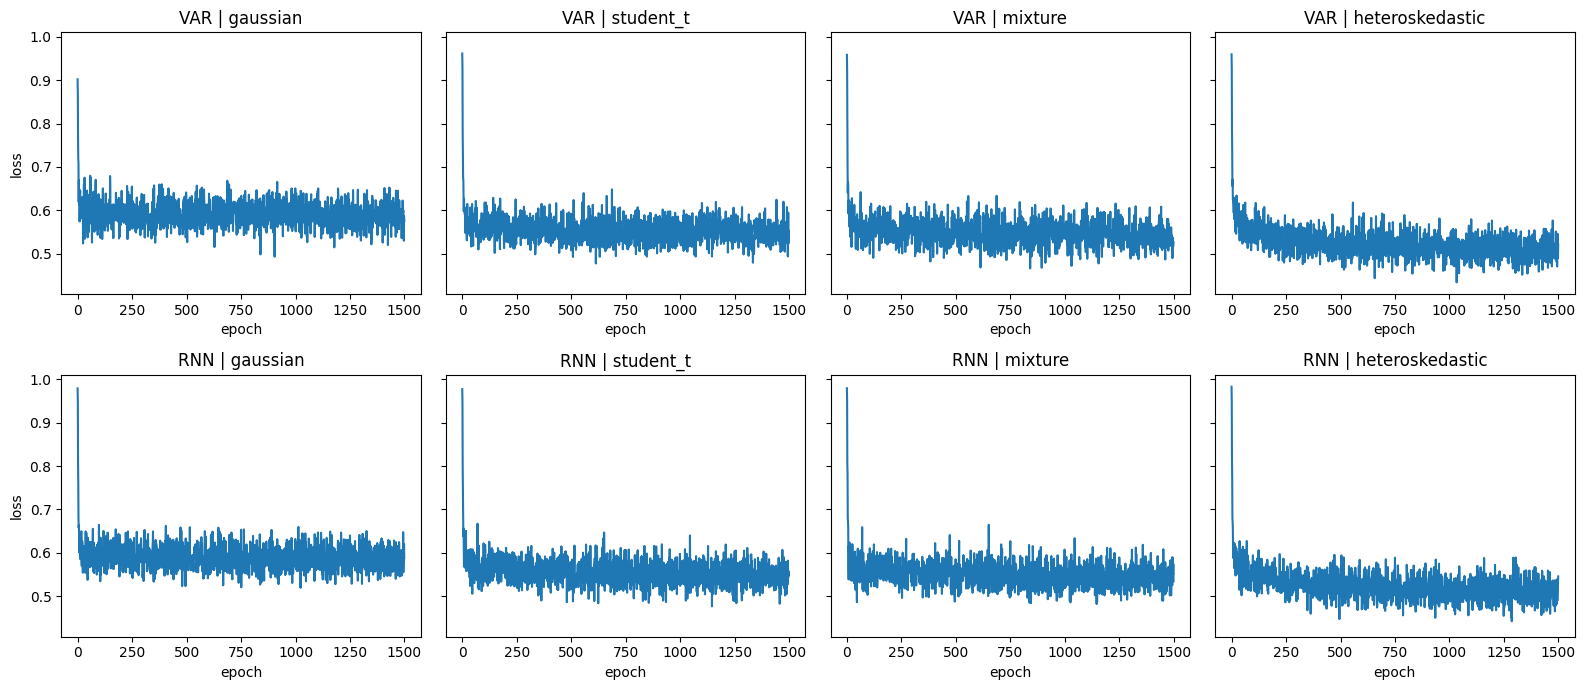

In [4]:
from src.plots.diffusion import (
    plot_diffusion_training_losses,
)

plot_diffusion_training_losses(
    diffusion_models=diffusion_models,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_current_figure(
    dirs["figures"]
    / "diffusion_training_losses.png"
)

print(
    "Saved: diffusion_training_losses.png"
)

In [5]:
from src.api.innovations import diffusion_diagnostics_table
diffusion_diag_df = diffusion_diagnostics_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_table(
    diffusion_diag_df,
    dirs["tables"] / "diffusion_diagnostics_by_series.csv",
)

diffusion_diag_df

,forecast_model,dgp,series,source,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,VAR,gaussian,1,empirical_residuals,1.422531e-16,1.010717,-0.075714,3.253305,0.253305,3.639653e-01
1,VAR,gaussian,1,diffusion,-1.060498e-03,1.024238,-0.040501,2.995078,-0.004922,2.533823e-01
2,VAR,gaussian,2,empirical_residuals,-4.170287e-17,0.996334,0.247366,3.271039,0.271039,2.075818e-02
3,VAR,gaussian,2,diffusion,1.691503e-02,1.030267,0.254681,3.101793,0.101793,4.045481e-25
4,VAR,gaussian,3,empirical_residuals,-1.595830e-16,1.039456,0.004211,3.021352,0.021352,9.975638e-01
5,VAR,gaussian,3,diffusion,8.600066e-02,1.036238,-0.040275,2.825358,-0.174642,4.338318e-04
6,VAR,student_t,1,empirical_residuals,-1.992470e-16,1.439405,0.690427,8.446322,5.446322,1.620289e-168
7,VAR,student_t,1,diffusion,-9.572779e-02,1.447571,0.004222,6.980716,3.980716,0.000000e+00
8,VAR,student_t,2,empirical_residuals,-8.525920e-18,1.399507,-0.686971,7.872340,4.872340,6.564223e-137
9,VAR,student_t,2,diffusion,-1.070552e-01,1.534996,-1.239423,12.232427,9.232427,0.000000e+00


In [6]:
from src.api.innovations import diffusion_diagnostics_summary

summary_df = diffusion_diagnostics_summary(
    diffusion_diag_df,
)

save_table(
    summary_df,
    dirs["tables"] / "diffusion_diagnostics_summary.csv",
)

summary_df

,forecast_model,dgp,source,mean,std,skewness,kurtosis,excess_kurtosis
0,RNN,gaussian,diffusion,7.603303e-02,0.900508,0.049976,3.234977,0.234977
1,RNN,gaussian,empirical_residuals,-1.280691e-02,0.941256,-0.032683,3.588507,0.588507
2,RNN,heteroskedastic,diffusion,7.498080e-02,1.789804,-0.090615,5.417508,2.417508
3,RNN,heteroskedastic,empirical_residuals,-1.683607e-02,1.849100,-0.243038,5.702470,2.702470
4,RNN,mixture,diffusion,1.172596e-01,1.466453,0.586134,9.056439,6.056439
5,RNN,mixture,empirical_residuals,-9.765846e-04,1.427922,-0.091890,8.344716,5.344716
6,RNN,student_t,diffusion,1.357367e-01,1.346142,-0.039053,10.975783,7.975783
7,RNN,student_t,empirical_residuals,1.816943e-03,1.394377,-0.267775,8.974455,5.974455
8,VAR,gaussian,diffusion,3.395173e-02,1.030247,0.057968,2.974076,-0.025924
9,VAR,gaussian,empirical_residuals,-1.967758e-17,1.015502,0.058621,3.181899,0.181899


Saved: diffusion_histogram_grid_4x4.png


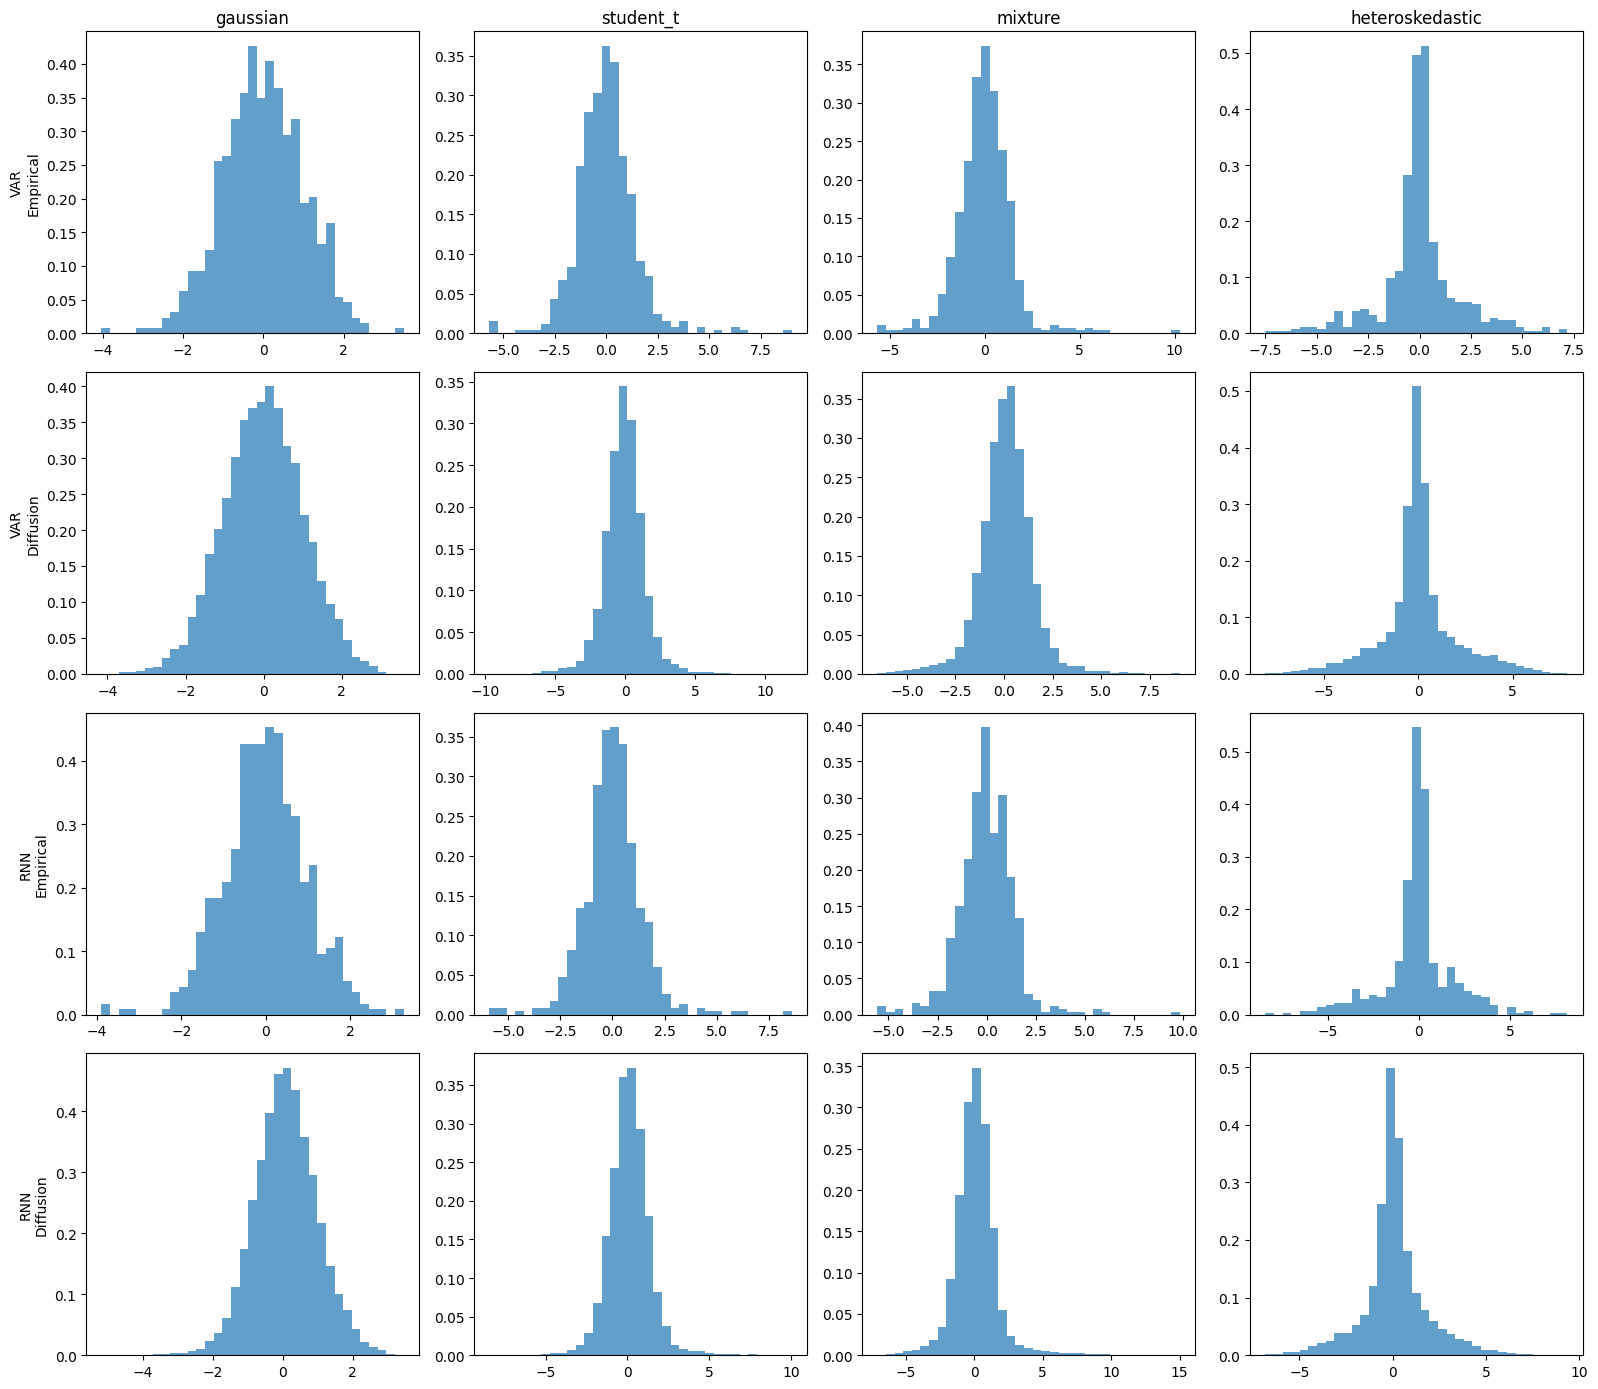

In [7]:
from src.plots.diffusion import plot_diffusion_histogram_grid

plot_diffusion_histogram_grid(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"] / "diffusion_histogram_grid_4x4.png"
)

print("Saved: diffusion_histogram_grid_4x4.png")

Saved: diffusion_qq_grid_4x4.png


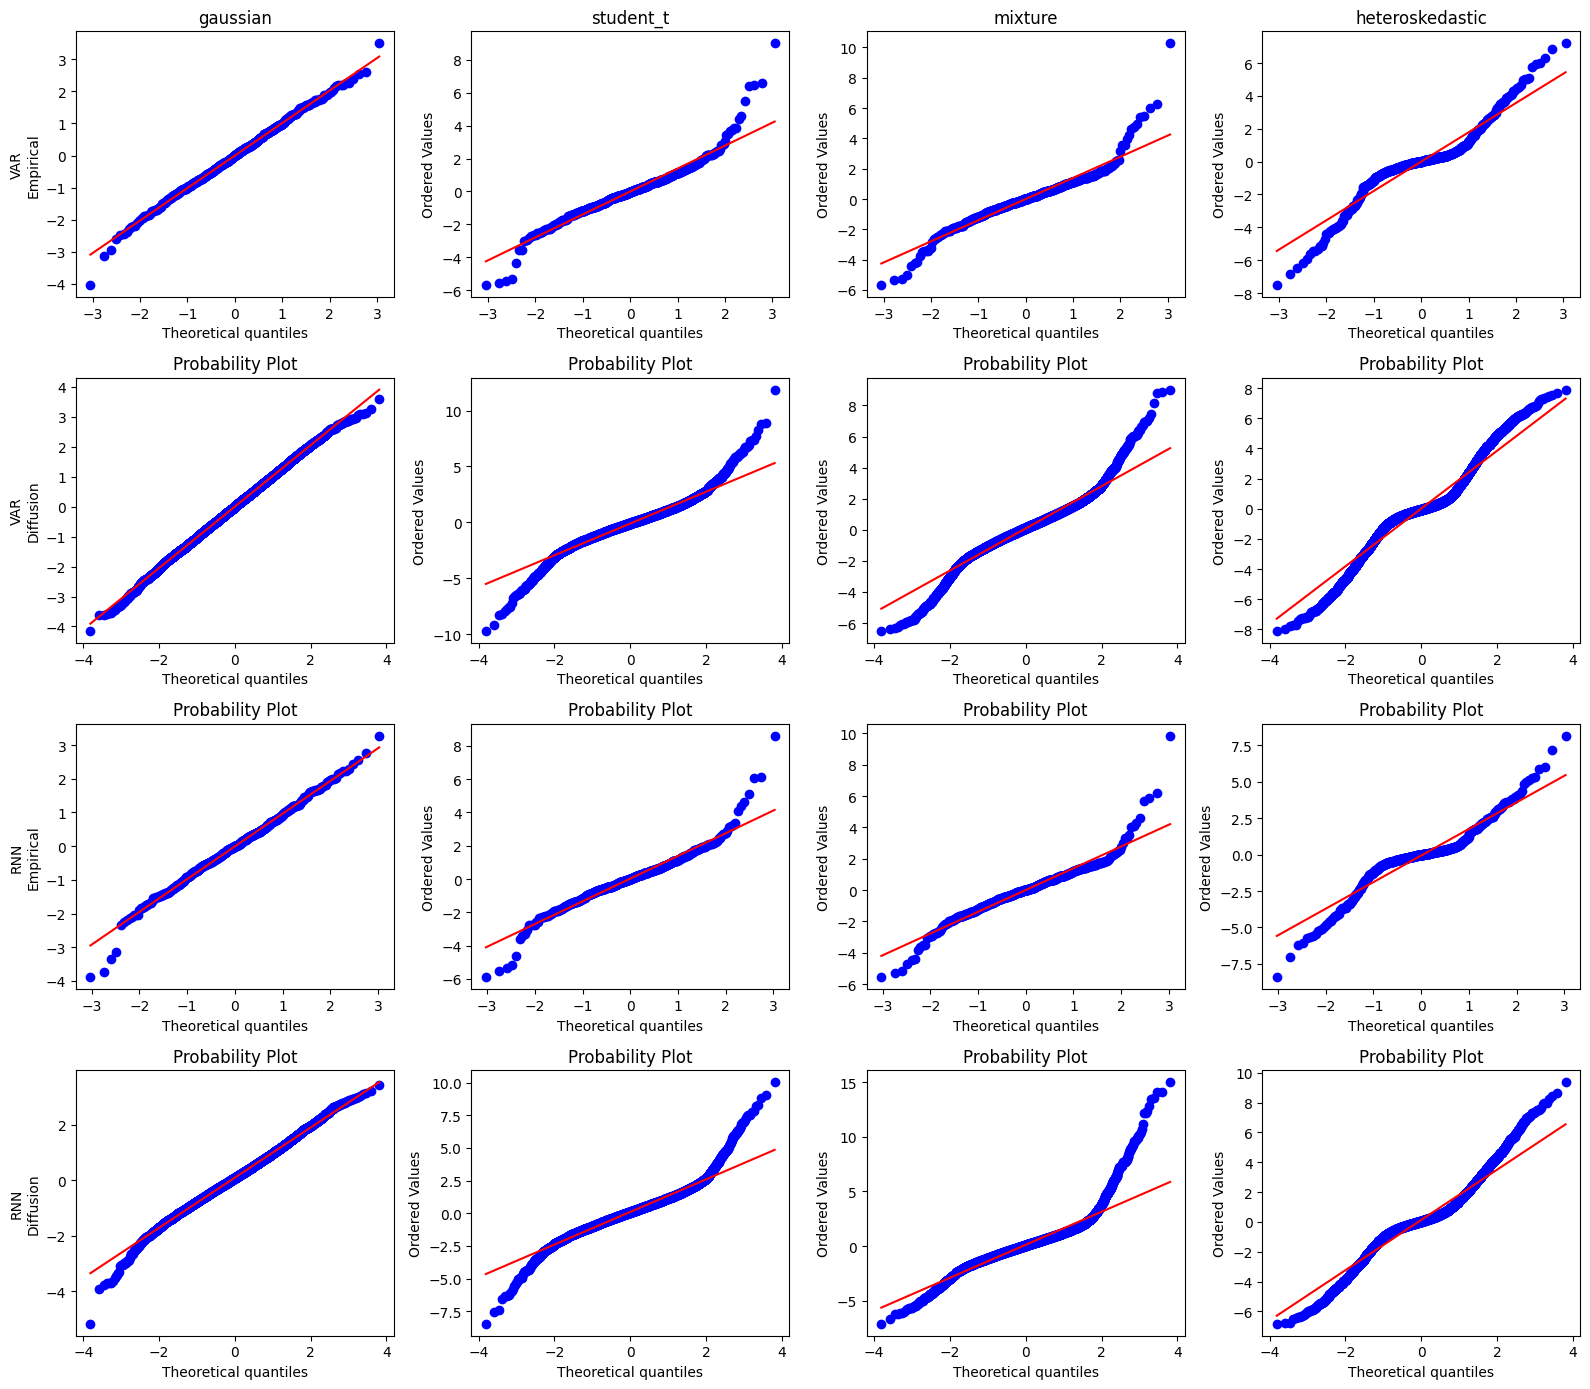

In [8]:
from src.plots.diffusion import plot_diffusion_qq_grid

plot_diffusion_qq_grid(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    dgp_names=dgp_names,
    variable=0,
)

save_current_figure(
    dirs["figures"]
    / "diffusion_qq_grid_4x4.png"
)

print(
    "Saved: diffusion_qq_grid_4x4.png"
)

In [9]:
from src.api.innovations import diffusion_quantile_recovery_table

quantiles = [
    0.01,
    0.05,
    0.50,
    0.95,
    0.99,
]

quantile_df = diffusion_quantile_recovery_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
    quantiles=quantiles,
)

save_table(
    quantile_df,
    dirs["tables"] / "diffusion_quantile_recovery.csv",
)

quantile_df

,forecast_model,dgp,series,quantile,empirical,diffusion,absolute_error
0,VAR,gaussian,1,0.01,-2.383039,-2.417925,0.034886
1,VAR,gaussian,1,0.05,-1.673637,-1.674409,0.000772
2,VAR,gaussian,1,0.50,0.001153,0.002674,0.001521
3,VAR,gaussian,1,0.95,1.638092,1.697876,0.059784
4,VAR,gaussian,1,0.99,2.189004,2.345695,0.156691
...,...,...,...,...,...,...,...
115,RNN,heteroskedastic,3,0.01,-5.850829,-4.624985,1.225844
116,RNN,heteroskedastic,3,0.05,-3.449030,-2.580492,0.868538
117,RNN,heteroskedastic,3,0.50,0.000984,0.127840,0.126856
118,RNN,heteroskedastic,3,0.95,3.493154,3.406972,0.086182


In [10]:
quantile_summary_df = (
    quantile_df
    .groupby(
        [
            "forecast_model",
            "dgp",
            "quantile",
        ]
    )["absolute_error"]
    .mean()
    .reset_index()
)

save_table(
    quantile_summary_df,
    dirs["tables"] / "diffusion_quantile_recovery_summary.csv",
)

quantile_summary_df

,forecast_model,dgp,quantile,absolute_error
0,RNN,gaussian,0.01,0.184216
1,RNN,gaussian,0.05,0.112475
2,RNN,gaussian,0.50,0.068672
3,RNN,gaussian,0.95,0.031664
4,RNN,gaussian,0.99,0.046507
5,RNN,heteroskedastic,0.01,0.911775
6,RNN,heteroskedastic,0.05,0.819455
7,RNN,heteroskedastic,0.50,0.074624
8,RNN,heteroskedastic,0.95,0.088274
9,RNN,heteroskedastic,0.99,0.265246


In [11]:
from src.api.innovations import diffusion_moment_error_table

moment_error_df = diffusion_moment_error_table(
    residual_store=residual_store,
    diffusion_samples=diffusion_samples,
    forecast_models=forecast_models,
    dgp_names=dgp_names,
)

save_table(
    moment_error_df,
    dirs["tables"] / "diffusion_moment_errors.csv",
)

moment_error_df

,forecast_model,dgp,mean_l2_error,cov_frobenius_error,skew_l2_error,kurtosis_l2_error
0,VAR,gaussian,0.087655,0.123180,0.057158,0.347041
1,VAR,student_t,0.160628,0.571486,0.880828,5.010052
2,VAR,mixture,0.221311,0.430642,1.209714,3.973171
3,VAR,heteroskedastic,0.339559,1.097245,0.534285,0.814692
4,RNN,gaussian,0.155868,0.169706,0.152330,0.611892
5,RNN,student_t,0.283366,0.392680,0.825787,5.262161
6,RNN,mixture,0.217532,0.687168,1.260088,3.846460
7,RNN,heteroskedastic,0.301660,1.080327,0.627853,0.482335


In [12]:
save_json(
    {
        "notebook": "05_diffusion",
        "forecast_models": forecast_models,
        "dgp_names": dgp_names,
        "diffusion_kwargs": {
            key: str(value)
            if "device" in key
            else value
            for key, value in diffusion_kwargs.items()
        },
        "models_saved": True,
        "samples_saved": True,
    },
    dirs["logs"] / "diffusion_config.json",
)

print(
    "05_diffusion completed."
)

05_diffusion completed.
